# CropSense AI – Model Training & Comparison

This notebook trains **5 models** for crop disease classification (Healthy, Powdery mildew, Rust) and selects the best by accuracy for use in the **CropSense** mobile app backend.

**Models:**
1. Logistic Regression  
2. Custom CNN (Adam + L1)  
3. MobileNetV2 (transfer learning)  
4. VGG16 (transfer learning)  
5. ResNet50V2 (transfer learning)  

**Dataset:** `dataset/Train` with subfolders `Healthy`, `Powdery`, `Rust` (same layout as used by the CropSense API).

## 1. Setup and paths (CropSense project)

In [1]:
import os
import json
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks, Model
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50V2

# Optional (nice heatmaps). Notebook still works without it.
try:
    import seaborn as sns
except Exception:
    sns = None

plt.style.use("seaborn-v0_8")

# CropSense project paths (works from repo root or training/)
PROJECT_ROOT = os.path.abspath(os.getcwd())
if os.path.basename(PROJECT_ROOT) == "training":
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
BASE_DIR = os.path.join(PROJECT_ROOT, "dataset", "Train")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
SAVED_MODELS_DIR = os.path.join(PROJECT_ROOT, "training", "saved_models")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SAVED_MODELS_DIR, exist_ok=True)

IMG_SIZE = (128, 128)
CLASSES = ["Healthy", "Powdery", "Rust"]  # Must match CropSense API
NUM_CLASSES = len(CLASSES)
RANDOM_STATE = 42
EPOCHS = 30
BATCH_SIZE = 32

print("CropSense project root:", PROJECT_ROOT)
print("Dataset:", BASE_DIR)
print("Outputs:", OUTPUT_DIR)

2026-03-19 05:01:51.300730: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


CropSense project root: /Users/diana/Documents/cropsenseai-mobile-app
Dataset: /Users/diana/Documents/cropsenseai-mobile-app/dataset/Train
Outputs: /Users/diana/Documents/cropsenseai-mobile-app/outputs


## 2. Load and split dataset

In [2]:
def clean_images(folder):
    for subdir in CLASSES:
        path = os.path.join(folder, subdir)
        if not os.path.isdir(path):
            continue
        for f in os.listdir(path):
            fp = os.path.join(path, f)
            try:
                Image.open(fp).verify()
            except Exception:
                try:
                    os.remove(fp)
                except Exception:
                    pass

def load_dataset(folder):
    X, y_raw = [], []
    for label in CLASSES:
        path = os.path.join(folder, label)
        if not os.path.isdir(path):
            print(f"Warning: {path} not found.")
            continue
        for f in os.listdir(path):
            fp = os.path.join(path, f)
            try:
                img = Image.open(fp).convert("RGB")
                img = img.resize(IMG_SIZE)
                X.append(np.array(img))
                y_raw.append(label)
            except Exception:
                continue
    if not X:
        raise FileNotFoundError(f"No images in {folder}. Need subdirs: {CLASSES}")
    X = np.array(X, dtype=np.float32) / 255.0
    return X, np.array(y_raw)

clean_images(BASE_DIR)
X, Y_raw = load_dataset(BASE_DIR)
print(f"Loaded {X.shape[0]} images, shape {X.shape}")

le = LabelEncoder()
Y = le.fit_transform(Y_raw)

X_train, X_rest, y_train, y_rest = train_test_split(X, Y, test_size=0.3, random_state=RANDOM_STATE, stratify=Y)
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=1/3, random_state=RANDOM_STATE, stratify=y_rest)
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Loaded 1532 images, shape (1532, 128, 128, 3)
Train: 1072, Val: 306, Test: 154


## 3. Model definitions (CropSense)

In [3]:
def build_custom_cnn(input_shape=(128, 128, 3), num_classes=3):
    reg = regularizers.l1(0.001)
    model = keras.Sequential([
        layers.Conv2D(32, 3, activation="relu", padding="same", kernel_regularizer=reg, input_shape=input_shape),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation="relu", padding="same", kernel_regularizer=reg),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, activation="relu", padding="same", kernel_regularizer=reg),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Flatten(), layers.Dense(128, activation="relu"), layers.Dense(64, activation="relu"),
        layers.Dropout(0.2), layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_mobilenetv2(input_shape=(128, 128, 3), num_classes=3):
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights="imagenet", pooling="avg")
    base.trainable = False
    x = layers.Dense(128, activation="relu")(base.output)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    model = Model(base.input, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_vgg16(input_shape=(128, 128, 3), num_classes=3):
    base = VGG16(input_shape=input_shape, include_top=False, weights="imagenet", pooling="avg")
    base.trainable = False
    x = layers.Dense(256, activation="relu")(base.output)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    model = Model(base.input, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_resnet50v2(input_shape=(128, 128, 3), num_classes=3):
    base = ResNet50V2(input_shape=input_shape, include_top=False, weights="imagenet", pooling="avg")
    base.trainable = False
    x = layers.Dense(128, activation="relu")(base.output)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    model = Model(base.input, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def eval_keras(model, X_test, y_test, name):
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    roc = roc_auc_score(y_test, y_pred_proba, multi_class="ovr", average="weighted") if len(np.unique(y_test)) > 1 else 0.0
    return {"model_name": name, "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
            "recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
            "f1": f1_score(y_test, y_pred, average="weighted", zero_division=0), "roc_auc": roc}

print("Model builders and eval_keras defined.")

Model builders and eval_keras defined.


## 4. Train all 5 models

In [4]:
results = []
best_model_info = None
best_accuracy = -1.0
early = callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True, mode="max")

In [5]:
# 1. Logistic Regression
print("--- 1/5: Logistic Regression ---")

print("LogisticRegression class:", LogisticRegression)
print("Module:", getattr(LogisticRegression, "__module__", "unknown"))

scaler = StandardScaler()
X_flat = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1))
X_test_flat = scaler.transform(X_test.reshape(X_test.shape[0], -1))

# NOTE: removed `multi_class=...` to avoid compatibility/shadowing issues
clf = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="saga",
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

clf.fit(X_flat, y_train)
y_pred_lr = clf.predict(X_test_flat)

roc_lr = (
    roc_auc_score(
        y_test,
        clf.predict_proba(X_test_flat),
        multi_class="ovr",
        average="weighted",
    )
    if len(np.unique(y_test)) > 1
    else 0.0
)

r1 = {
    "model_name": "Logistic Regression",
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr, average="weighted", zero_division=0),
    "recall": recall_score(y_test, y_pred_lr, average="weighted", zero_division=0),
    "f1": f1_score(y_test, y_pred_lr, average="weighted", zero_division=0),
    "roc_auc": roc_lr,
}
results.append(r1)

if r1["accuracy"] > best_accuracy:
    best_accuracy = r1["accuracy"]
    best_model_info = ("lr", clf, {"scaler": scaler, "label_encoder": le})

print(r1)

--- 1/5: Logistic Regression ---
LogisticRegression class: <class 'sklearn.linear_model._logistic.LogisticRegression'>
Module: sklearn.linear_model._logistic


/Users/diana/Documents/cropsenseai-mobile-app/.ml_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


{'model_name': 'Logistic Regression', 'accuracy': 0.7792207792207793, 'precision': 0.7845667328034045, 'recall': 0.7792207792207793, 'f1': 0.7770137084653214, 'roc_auc': 0.9171990114566776}


/Users/diana/Documents/cropsenseai-mobile-app/.ml_venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [6]:
# 2. Custom CNN (Adam + L1)
print("--- 2/5: Custom CNN ---")
custom_cnn = build_custom_cnn(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
custom_cnn.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[early], verbose=1)
r2 = eval_keras(custom_cnn, X_test, y_test, "Custom CNN (Adam+L1)")
results.append(r2)
if r2["accuracy"] > best_accuracy:
    best_accuracy = r2["accuracy"]
    best_model_info = ("custom_cnn", custom_cnn, {"label_encoder": le})
print(r2)

--- 2/5: Custom CNN ---


/Users/diana/Documents/cropsenseai-mobile-app/.ml_venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 593ms/step - accuracy: 0.7052 - loss: 3.7525 - val_accuracy: 0.3268 - val_loss: 4.3689
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1735s 25s/step - accuracy: 0.8927 - loss: 3.2267 - val_accuracy: 0.3627 - val_loss: 4.7264
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 743ms/step - accuracy: 0.9366 - loss: 3.0832 - val_accuracy: 0.5850 - val_loss: 5.1576
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 607ms/step - accuracy: 0.9720 - loss: 2.9702 - val_accuracy: 0.4020 - val_loss: 5.7079
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 597ms/step - accuracy: 0.9907 - loss: 2.8859 - val_accuracy: 0.5621 - val_loss: 5.8766
Epoch 6/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1884s 57s/step - accuracy: 0.9897 - loss: 2.8404 - val_accuracy: 0.6176 - val_loss: 6.0129
Epoch 7/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 982s 30s/step - accuracy: 0.9916 - loss: 2.7888 - val_accuracy: 0.6340 - val_loss: 5.3608
Epoch 8/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 1026s 31s/step - accuracy: 0.9953 - loss: 2.7368 - val_accur

In [7]:
# 3. MobileNetV2
print("--- 3/5: MobileNetV2 ---")
mobilenet = build_mobilenetv2(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
history_mobilenet = mobilenet.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early],
    verbose=1,
)
r3 = eval_keras(mobilenet, X_test, y_test, "MobileNetV2")
results.append(r3)
if r3["accuracy"] > best_accuracy:
    best_accuracy = r3["accuracy"]
    best_model_info = ("mobilenetv2", mobilenet, {"label_encoder": le})
print(r3)

--- 3/5: MobileNetV2 ---
Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 452ms/step - accuracy: 0.8554 - loss: 0.3587 - val_accuracy: 0.9641 - val_loss: 0.1323
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 383ms/step - accuracy: 0.9729 - loss: 0.0933 - val_accuracy: 0.9379 - val_loss: 0.1805
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 390ms/step - accuracy: 0.9767 - loss: 0.0626 - val_accuracy: 0.9673 - val_loss: 0.1074
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 374ms/step - accuracy: 0.9907 - loss: 0.0389 - val_accuracy: 0.9673 - val_loss: 0.1050
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 364ms/step - accuracy: 0.9963 - loss: 0.0222 - val_accuracy: 0.9673 - val_loss: 0.1011
Epoch 6/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 401ms/step - accuracy: 0.9953 - loss: 0.0165 - val_accuracy: 0.9771 - val_loss: 0.1032
Epoch 7/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 15s 442ms/step - accuracy: 0.9981 - loss: 0.0108 - val_accuracy: 0.9673 - val_loss: 0.1106
Epoch 8/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 401ms/step - accuracy: 0.9981 

In [8]:
# 4. VGG16
print("--- 4/5: VGG16 ---")
vgg = build_vgg16(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
vgg.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[early], verbose=1)
r4 = eval_keras(vgg, X_test, y_test, "VGG16")
results.append(r4)
if r4["accuracy"] > best_accuracy:
    best_accuracy = r4["accuracy"]
    best_model_info = ("vgg16", vgg, {"label_encoder": le})
print(r4)

--- 4/5: VGG16 ---
Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.5103 - loss: 0.9627 - val_accuracy: 0.7712 - val_loss: 0.7004
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.7332 - loss: 0.6783 - val_accuracy: 0.7712 - val_loss: 0.5854
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.7565 - loss: 0.5894 - val_accuracy: 0.8072 - val_loss: 0.5162
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.7994 - loss: 0.5238 - val_accuracy: 0.8301 - val_loss: 0.4667
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.8181 - loss: 0.4897 - val_accuracy: 0.8333 - val_loss: 0.4467
{'model_name': 'VGG16', 'accuracy': 0.7662337662337663, 'precision': 0.7678721264959038, 'recall': 0.7662337662337663, 'f1': 0.7636823832759215, 'roc_auc': 0.9203197972363115}


In [9]:
# 5. ResNet50V2
print("--- 5/5: ResNet50V2 ---")
resnet = build_resnet50v2(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
resnet.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[early], verbose=1)
r5 = eval_keras(resnet, X_test, y_test, "ResNet50V2")
results.append(r5)
if r5["accuracy"] > best_accuracy:
    best_accuracy = r5["accuracy"]
    best_model_info = ("resnet50v2", resnet, {"label_encoder": le})
print(r5)

--- 5/5: ResNet50V2 ---
Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 34s 777ms/step - accuracy: 0.8116 - loss: 0.4734 - val_accuracy: 0.9020 - val_loss: 0.2596
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 754ms/step - accuracy: 0.9244 - loss: 0.2112 - val_accuracy: 0.9183 - val_loss: 0.2247
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 723ms/step - accuracy: 0.9496 - loss: 0.1458 - val_accuracy: 0.9183 - val_loss: 0.1906
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 734ms/step - accuracy: 0.9674 - loss: 0.0906 - val_accuracy: 0.9281 - val_loss: 0.1839
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 778ms/step - accuracy: 0.9795 - loss: 0.0778 - val_accuracy: 0.9477 - val_loss: 0.1697
{'model_name': 'ResNet50V2', 'accuracy': 0.9675324675324676, 'precision': 0.9704313543599257, 'recall': 0.9675324675324676, 'f1': 0.9677489646253702, 'roc_auc': 0.9989837736040754}


## 5. Compare models and save best (CropSense)

The best model is saved so the CropSense API can load it from `outputs/best_model.keras` or `training/saved_models/best_model_lr.pkl`.

In [10]:
df = pd.DataFrame(results).sort_values("accuracy", ascending=False).reset_index(drop=True)
print("CropSense – Model comparison (by accuracy)")
print(df.to_string(index=False))
print("\nBest:", df.iloc[0]["model_name"], "— accuracy:", round(df.iloc[0]["accuracy"], 4))
df.to_csv(os.path.join(SAVED_MODELS_DIR, "model_comparison.csv"), index=False)

CropSense – Model comparison (by accuracy)
          model_name  accuracy  precision   recall       f1  roc_auc
         MobileNetV2  0.993506   0.993634 0.993506 0.993506 0.999434
          ResNet50V2  0.967532   0.970431 0.967532 0.967749 0.998984
Custom CNN (Adam+L1)  0.922078   0.922292 0.922078 0.921658 0.993427
 Logistic Regression  0.779221   0.784567 0.779221 0.777014 0.917199
               VGG16  0.766234   0.767872 0.766234 0.763682 0.920320

Best: MobileNetV2 — accuracy: 0.9935


In [11]:
# Save best model and CropSense metadata
if best_model_info:
    name, model_obj, extra = best_model_info
    if name == "lr":
        import joblib
        path = os.path.join(SAVED_MODELS_DIR, "best_model_lr.pkl")
        joblib.dump({"model": model_obj, "scaler": extra["scaler"], "label_encoder": extra["label_encoder"]}, path)
        print("Saved best (LR) to", path)
    else:
        path = os.path.join(OUTPUT_DIR, "best_model.keras")
        model_obj.save(path)
        print("Saved best (" + name + ") to", path)
    with open(os.path.join(OUTPUT_DIR, "model_metadata.json"), "w") as f:
        json.dump({"class_names": CLASSES}, f, indent=2)
    print("Saved class names to outputs/model_metadata.json")

Saved best (mobilenetv2) to /Users/diana/Documents/cropsenseai-mobile-app/outputs/best_model.keras
Saved class names to outputs/model_metadata.json


## 6. Visualizations (required for report)

This section generates plots/figures to include in your capstone report:
- Dataset class distribution
- Sample images per class
- MobileNetV2 training curves (accuracy/loss)
- Model comparison bar chart
- Confusion matrix + classification report (best model)


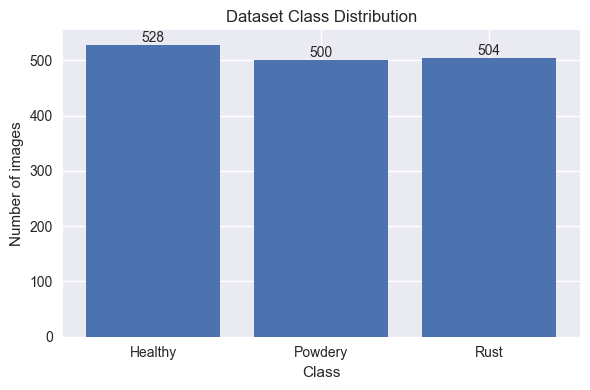

In [ ]:
# 6.1 Dataset class distribution

counts = pd.Series(Y_raw).value_counts().reindex(CLASSES, fill_value=0)
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of images")
for i, v in enumerate(counts.values):
    plt.text(i, v + max(counts.values) * 0.01, str(v), ha="center")
plt.tight_layout()
plt.show()

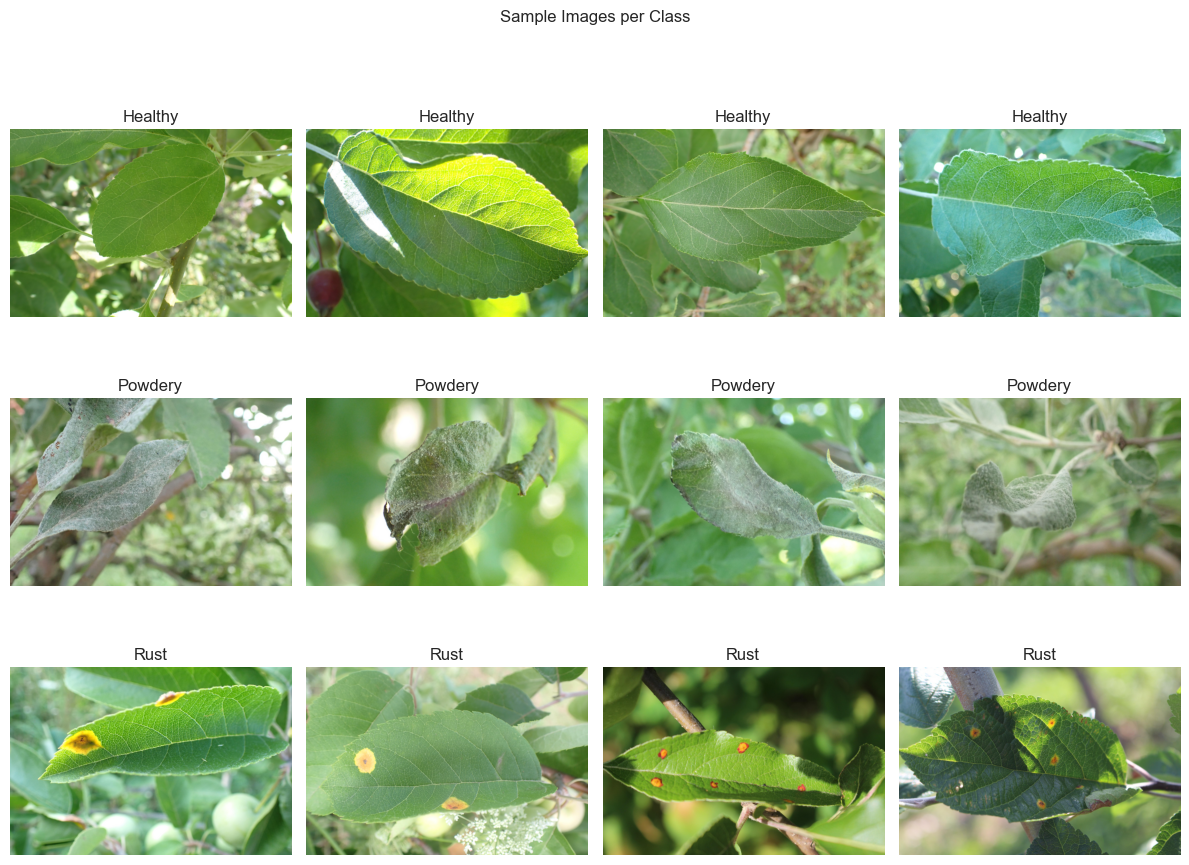

In [ ]:
# 6.2 Sample images grid (per class)

def show_samples_per_class(folder: str, samples_per_class: int = 4):
    fig, axes = plt.subplots(len(CLASSES), samples_per_class, figsize=(samples_per_class * 3, len(CLASSES) * 3))
    if len(CLASSES) == 1:
        axes = np.array([axes])

    for r, label in enumerate(CLASSES):
        class_dir = os.path.join(folder, label)
        files = [f for f in os.listdir(class_dir) if not f.startswith('.')]
        if not files:
            for c in range(samples_per_class):
                axes[r, c].axis("off")
            continue
        np.random.shuffle(files)
        pick = files[:samples_per_class]

        for c in range(samples_per_class):
            ax = axes[r, c]
            if c < len(pick):
                img = Image.open(os.path.join(class_dir, pick[c])).convert("RGB")
                ax.imshow(img)
                ax.set_title(label)
            ax.axis("off")

    plt.suptitle("Sample Images per Class", y=1.02)
    plt.tight_layout()
    plt.show()

show_samples_per_class(BASE_DIR, samples_per_class=4)

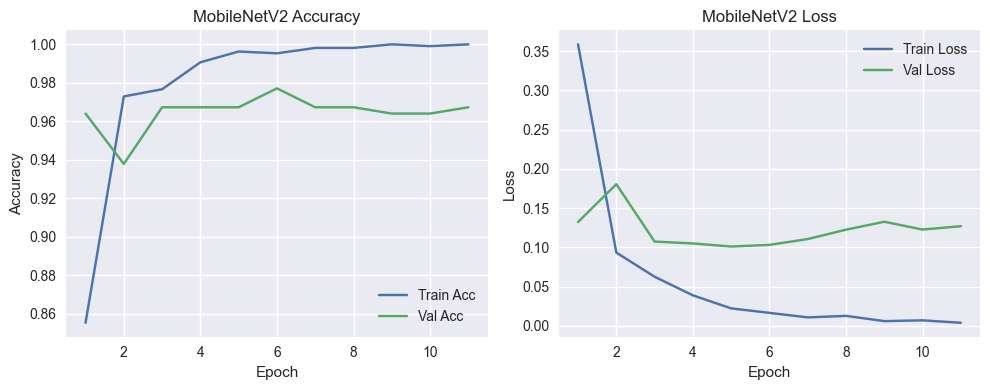

In [ ]:
# 6.3 Training curves (MobileNetV2)
# Requires `history_mobilenet` from the MobileNetV2 training cell.

if 'history_mobilenet' not in globals():
    raise RuntimeError("history_mobilenet not found. Run the MobileNetV2 training cell first.")

hist = history_mobilenet.history
epochs = range(1, len(hist.get('loss', [])) + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, hist.get('accuracy', []), label='Train Acc')
plt.plot(epochs, hist.get('val_accuracy', []), label='Val Acc')
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, hist.get('loss', []), label='Train Loss')
plt.plot(epochs, hist.get('val_loss', []), label='Val Loss')
plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

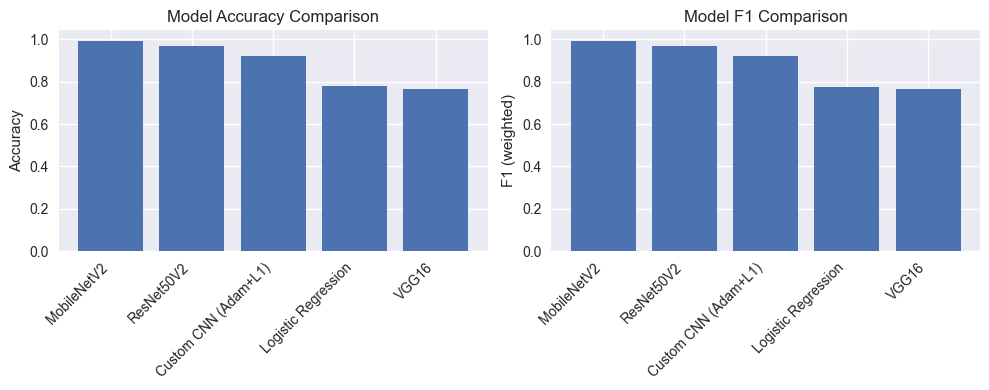

In [15]:
# 6.4 Model comparison bar chart (Accuracy, F1)
# Requires `df` from the comparison cell.

if 'df' not in globals():
    raise RuntimeError("df not found. Run the 'Compare models' cell first.")

plot_df = df.copy()
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(plot_df['model_name'], plot_df['accuracy'])
plt.xticks(rotation=45, ha='right')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.bar(plot_df['model_name'], plot_df['f1'])
plt.xticks(rotation=45, ha='right')
plt.title('Model F1 Comparison')
plt.ylabel('F1 (weighted)')

plt.tight_layout()
plt.show()

Best model from comparison: MobileNetV2


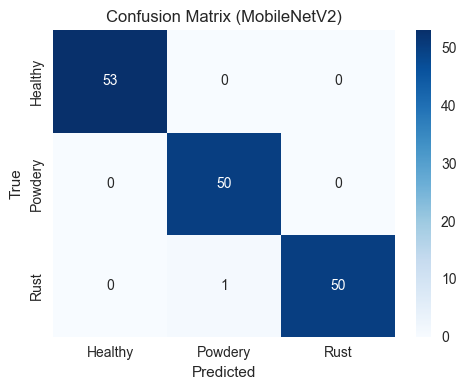


Classification report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        53
     Powdery       0.98      1.00      0.99        50
        Rust       1.00      0.98      0.99        51

    accuracy                           0.99       154
   macro avg       0.99      0.99      0.99       154
weighted avg       0.99      0.99      0.99       154



In [16]:
# 6.5 Confusion matrix + classification report (best model)

# Determine best model name from df
best_name = df.iloc[0]['model_name'] if 'df' in globals() and len(df) else None
print('Best model from comparison:', best_name)

# For this project, MobileNetV2 is expected to be best. If not, we still try to evaluate what we have.
model_for_cm = None
if best_name == 'MobileNetV2' and 'mobilenet' in globals():
    model_for_cm = mobilenet
elif best_name == 'ResNet50V2' and 'resnet' in globals():
    model_for_cm = resnet
elif best_name == 'VGG16' and 'vgg' in globals():
    model_for_cm = vgg
elif best_name == 'Custom CNN (Adam+L1)' and 'custom_cnn' in globals():
    model_for_cm = custom_cnn

if model_for_cm is None:
    raise RuntimeError("Best Keras model not found in globals. Run training cells first.")

# Predict
y_proba = model_for_cm.predict(X_test, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
if sns is not None:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
else:
    plt.imshow(cm, cmap='Blues')
    plt.colorbar()
    plt.xticks(range(len(CLASSES)), CLASSES, rotation=45, ha='right')
    plt.yticks(range(len(CLASSES)), CLASSES)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.title(f'Confusion Matrix ({best_name})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Classification report
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=CLASSES, zero_division=0))

In [17]:
# 6.6 Save figures to docs/figures/

FIG_DIR = os.path.join(PROJECT_ROOT, "docs", "figures")
os.makedirs(FIG_DIR, exist_ok=True)
print("Saving figures to:", FIG_DIR)

# Helper to save and close

def _save_fig(path: str):
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()

# (1) Class distribution
counts = pd.Series(Y_raw).value_counts().reindex(CLASSES, fill_value=0)
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of images")
for i, v in enumerate(counts.values):
    plt.text(i, v + max(counts.values) * 0.01, str(v), ha="center")
_save_fig(os.path.join(FIG_DIR, "01_dataset_class_distribution.png"))

# (2) Sample images grid
samples_per_class = 4
fig, axes = plt.subplots(len(CLASSES), samples_per_class, figsize=(samples_per_class * 3, len(CLASSES) * 3))
if len(CLASSES) == 1:
    axes = np.array([axes])

for r, label in enumerate(CLASSES):
    class_dir = os.path.join(BASE_DIR, label)
    files = [f for f in os.listdir(class_dir) if not f.startswith('.')]
    np.random.shuffle(files)
    pick = files[:samples_per_class]
    for c in range(samples_per_class):
        ax = axes[r, c]
        if c < len(pick):
            img = Image.open(os.path.join(class_dir, pick[c])).convert("RGB")
            ax.imshow(img)
            ax.set_title(label)
        ax.axis("off")
plt.suptitle("Sample Images per Class", y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_sample_images_per_class.png"), dpi=200, bbox_inches="tight")
plt.close(fig)

# (3) MobileNetV2 training curves
if 'history_mobilenet' in globals():
    hist = history_mobilenet.history
    epochs = range(1, len(hist.get('loss', [])) + 1)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist.get('accuracy', []), label='Train Acc')
    plt.plot(epochs, hist.get('val_accuracy', []), label='Val Acc')
    plt.title('MobileNetV2 Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist.get('loss', []), label='Train Loss')
    plt.plot(epochs, hist.get('val_loss', []), label='Val Loss')
    plt.title('MobileNetV2 Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    _save_fig(os.path.join(FIG_DIR, "03_mobilenetv2_training_curves.png"))
else:
    print("Skipping training curves: history_mobilenet not found. Run the MobileNetV2 training cell first.")

# (4) Model comparison charts
if 'df' in globals():
    plot_df = df.copy()
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.bar(plot_df['model_name'], plot_df['accuracy'])
    plt.xticks(rotation=45, ha='right')
    plt.title('Model Accuracy Comparison')
    plt.ylabel('Accuracy')

    plt.subplot(1, 2, 2)
    plt.bar(plot_df['model_name'], plot_df['f1'])
    plt.xticks(rotation=45, ha='right')
    plt.title('Model F1 Comparison')
    plt.ylabel('F1 (weighted)')

    _save_fig(os.path.join(FIG_DIR, "04_model_comparison_accuracy_f1.png"))
else:
    print("Skipping model comparison chart: df not found. Run the comparison cell first.")

# (5) Confusion matrix + classification report for best model
if 'df' in globals() and len(df):
    best_name = df.iloc[0]['model_name']

    model_for_cm = None
    if best_name == 'MobileNetV2' and 'mobilenet' in globals():
        model_for_cm = mobilenet
    elif best_name == 'ResNet50V2' and 'resnet' in globals():
        model_for_cm = resnet
    elif best_name == 'VGG16' and 'vgg' in globals():
        model_for_cm = vgg
    elif best_name == 'Custom CNN (Adam+L1)' and 'custom_cnn' in globals():
        model_for_cm = custom_cnn

    if model_for_cm is not None:
        y_proba = model_for_cm.predict(X_test, verbose=0)
        y_pred = np.argmax(y_proba, axis=1)
        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(5, 4))
        if sns is not None:
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
        else:
            plt.imshow(cm, cmap='Blues')
            plt.colorbar()
            plt.xticks(range(len(CLASSES)), CLASSES, rotation=45, ha='right')
            plt.yticks(range(len(CLASSES)), CLASSES)
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
        plt.title(f'Confusion Matrix ({best_name})')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        _save_fig(os.path.join(FIG_DIR, "05_confusion_matrix.png"))

        report = classification_report(y_test, y_pred, target_names=CLASSES, zero_division=0)
        with open(os.path.join(FIG_DIR, "06_classification_report.txt"), "w") as f:
            f.write(f"Best model: {best_name}\n\n")
            f.write(report)
        print("Saved classification report to 06_classification_report.txt")
    else:
        print("Skipping confusion matrix: best model object not found. Run training cells first.")

print("Done. Saved figures:")
for f in sorted(os.listdir(FIG_DIR)):
    print("-", f)

Saving figures to: /Users/diana/Documents/cropsenseai-mobile-app/docs/figures
Saved classification report to 06_classification_report.txt
Done. Saved figures:
- 01_dataset_class_distribution.png
- 02_sample_images_per_class.png
- 03_mobilenetv2_training_curves.png
- 04_model_comparison_accuracy_f1.png
- 05_confusion_matrix.png
- 06_classification_report.txt
